#**Izaz Khan**  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN                                                                        
**Assignment:** 2 -> Two_Layer_net.ipynb                                                                      
***Date:*** 17/02/2026

#**Setup**
I am setting up the folder path and mounting to drive.

In [10]:
# I am setting the folder name based on your Drive screenshot
FOLDERNAME = 'assignment1'

import sys
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# I am fixing Python 3.12 compatibility for the 'autoreload' extension
try:
    import imp
except ImportError:
    import importlib, types
    imp = types.ModuleType('imp')
    imp.reload = importlib.reload
    sys.modules['imp'] = imp

%load_ext autoreload
%autoreload 2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Library Imports and Setup**
I am importing the necessary modules for Assignment 2, including the modular layers and the solver required for training the network

In [12]:
# I am importing the core libraries and the assignment-specific modules
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.fc_net import TwoLayerNet
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

def rel_error(x, y):
    """ I am using this to check the accuracy of the gradients """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

#**Loading CIFAR-10 Data**
I am loading the dataset into memory so I can use it to train and validate the two-layer neural network.


In [13]:
# I am loading the data and verifying the shapes of the image batches
data = get_CIFAR10_data()
for k, v in list(data.items()):
  print(('%s: ' % k, v.shape))

('X_train: ', (49000, 3, 32, 32))
('y_train: ', (49000,))
('X_val: ', (1000, 3, 32, 32))
('y_val: ', (1000,))
('X_test: ', (1000, 3, 32, 32))
('y_test: ', (1000,))


#**Affine Layer Forward Pass Implementation**
I am implementing the affine_forward function, which performs a linear transformation on the input data. I reshape the input into a vector and compute the matrix product with the weights before adding the bias

In [14]:
def affine_forward(x, w, b):
    N = x.shape[0]
    x_reshaped = x.reshape(N, -1)
    out = np.dot(x_reshaped, w) + b
    cache = (x, w, b)
    return out, cache

#**Testing Affine Forward**
I am executing a test of the affine_forward implementation using a set of fixed toy inputs and weights. I compare my calculated output against the known correct values to ensure the relative error is minimal.

In [15]:
num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3

input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

out, _ = affine_forward(x, w, b)
correct_out = np.array([[ 1.49834967,  1.70660132,  1.91485297],
                        [ 3.25553199,  3.5141327,   3.77273342]])

print('Testing affine_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing affine_forward function:
difference:  9.769849468192957e-10


#**Affine Layer Backward Pass Implementation**
I am now implementing the affine_backward function in cs231n/layers.py to calculate the gradients of the loss with respect to the inputs, weights, and biases. I use the chain rule to propagate the upstream gradient (dout) back through the linear transformation.

In [16]:
def affine_backward(dout, cache):
    x, w, b = cache
    dx = np.dot(dout, w.T).reshape(x.shape)
    dw = np.dot(x.reshape(x.shape[0], -1).T, dout)
    db = np.sum(dout, axis=0)
    return dx, dw, db

#**Testing Affine Backward**
I am executing a gradient check for the affine_backward function by comparing my analytical gradients against numerical gradients computed by slightly perturbing the inputs. I expect the relative error for dx, dw, and db to be very small, typically around 1e-10 or less.

In [17]:
np.random.seed(231)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)

dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)

_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

print('Testing affine_backward function:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_backward function:
dx error:  5.399100368651805e-11
dw error:  9.904211865398145e-11
db error:  2.4122867568119087e-11


#**Step 8: ReLU Forward Pass**
I am implementing the relu_forward function in cs231n/layers.py. This function applies the rectified linear unit activation, which threshold inputs at zero to introduce non-linearity.

In [18]:
def relu_forward(x):
    out = np.maximum(0, x)
    cache = x
    return out, cache

#**Testing ReLU Forward**
I am testing the relu_forward implementation using a range of values. I verify the output against expected results to ensure negative values are correctly zeroed out.

In [19]:
x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)
out, _ = relu_forward(x)
correct_out = np.array([[ 0.,          0.,          0.,          0.,        ],
                        [ 0.,          0.,          0.04545455,  0.13636364,],
                        [ 0.22727273,  0.31818182,  0.40909091,  0.5,       ]])

print('Testing relu_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing relu_forward function:
difference:  4.999999798022158e-08


#**ReLU Backward Pass**
I am implementing the relu_backward function in cs231n/layers.py. I set the gradient to zero for any input that was less than or equal to zero during the forward pass.

In [20]:
def relu_backward(dout, cache):
    x = cache
    dx = dout * (x > 0)
    return dx

#**Testing ReLU Backward**
I am conducting a numeric gradient check to verify the relu_backward implementation. I expect the relative error to be extremely small, around 1e-12.

In [21]:
np.random.seed(231)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)

dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)

_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

print('Testing relu_backward function:')
print('dx error: ', rel_error(dx_num, dx))

Testing relu_backward function:
dx error:  3.2756349136310288e-12


#**Inline Question 1**

I am answering the conceptual question regarding gradient flow in activation functions. I analyze which functions suffer from vanishing gradients based on their mathematical properties in the one-dimensional case.

**$\color{blue}{\textit  Answer:}$**  
Sigmoid  
ReLU  

**$\color{blue}{\textit  Explanation:}$**

**Sigmoid:**  
This function suffers from the vanishing gradient problem because it saturates at both extremes (very large positive or negative inputs). In these regions, the derivative approaches zero, which effectively stops gradient flow.

**ReLU:**  
ReLU has a zero gradient for all negative inputs ($x < 0$). This can create "dead ReLUs," where neurons stop updating entirely if they are never activated.

**Leaky ReLU:**  
This activation does not usually suffer from this issue because it preserves a small, non-zero gradient for negative inputs, allowing learning to continue.


#**Testing Sandwich Layers**
I am testing the affine_relu_forward and affine_relu_backward helper functions. These combine the affine and ReLU operations into a single step to simplify the network architecture.

In [28]:
def affine_relu_forward(x, w, b):
    # I compute the linear transformation and then apply ReLU
    a, fc_cache = affine_forward(x, w, b)
    out, relu_cache = relu_forward(a)
    cache = (fc_cache, relu_cache)
    return out, cache

def affine_relu_backward(dout, cache):
    # I backpropagate through ReLU and then the affine layer
    fc_cache, relu_cache = cache
    da = relu_backward(dout, relu_cache)
    dx, dw, db = affine_backward(da, fc_cache)
    return dx, dw, db

In [30]:
# I am testing the combined layers with numerical gradient checking
np.random.seed(231)
x = np.random.randn(2, 3, 4)
w = np.random.randn(12, 10)
b = np.random.randn(10)
dout = np.random.randn(2, 10)

out, cache = affine_relu_forward(x, w, b)
dx, dw, db = affine_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)

print('Testing affine_relu_forward and affine_relu_backward:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_relu_forward and affine_relu_backward:
dx error:  2.299579177309368e-11
dw error:  8.162011105764925e-11
db error:  7.826724021458994e-12


#**Loss Layers (Softmax)**
I am implementing the softmax_loss function in cs231n/layers.py. This function computes the cross-entropy loss and the gradient with respect to the inputs, which is necessary for training the network.

In [31]:
def softmax_loss(x, y):
    shifted_logits = x - np.max(x, axis=1, keepdims=True)
    Z = np.sum(np.exp(shifted_logits), axis=1, keepdims=True)
    log_probs = shifted_logits - np.log(Z)
    probs = np.exp(log_probs)
    N = x.shape[0]
    loss = -np.sum(log_probs[np.arange(N), y]) / N
    dx = probs.copy()
    dx[np.arange(N), y] -= 1
    dx /= N
    return loss, dx

#**Testing Softmax Loss**
I am verifying the softmax_loss implementation by checking the initial loss value and the numerical gradients. I expect the initial loss to be close to $\log(10) \approx 2.3$ for 10 classes and the gradient errors to be around 1e-8.

In [32]:
np.random.seed(231)
num_classes, num_inputs = 10, 50
x = 0.001 * np.random.randn(num_inputs, num_classes)
y = np.random.randint(num_classes, size=num_inputs)

dx_num = eval_numerical_gradient(lambda x: softmax_loss(x, y)[0], x, verbose=False)
loss, dx = softmax_loss(x, y)

print('Testing softmax_loss:')
print('loss: ', loss)
print('dx error: ', rel_error(dx_num, dx))

Testing softmax_loss:
loss:  2.302545844500738
dx error:  9.384673161989355e-09


#**Initializing the Two-Layer Net**
I am implementing the __init__ method in cs231n/classifiers/fc_net.py. I initialize the weights with small random values and the biases to zero, ensuring the shapes match the input, hidden, and output dimensions.

In [36]:
def __init__(self, input_dim=3*32*32, hidden_dim=100, num_classes=10,
             weight_scale=1e-3, reg=0.0):
    self.params = {}
    self.reg = reg

    # I initialize weights for the first layer (input to hidden)
    self.params['W1'] = weight_scale * np.random.randn(input_dim, hidden_dim)
    self.params['b1'] = np.zeros(hidden_dim)

    # I initialize weights for the second layer (hidden to output)
    self.params['W2'] = weight_scale * np.random.randn(hidden_dim, num_classes)
    self.params['b2'] = np.zeros(num_classes)

#**Two-Layer Net Loss and Gradients**
I am implementing the loss function in cs231n/classifiers/fc_net.py. I perform a forward pass through the hidden ReLU layer and the output layer, calculate the softmax loss with L2 regularization, and then compute the gradients using backpropagation.

In [43]:
def loss(self, X, y=None):
    W1, b1 = self.params['W1'], self.params['b1']
    W2, b2 = self.params['W2'], self.params['b2']

    # I compute the first layer: Affine -> ReLU
    h1, h1_cache = affine_relu_forward(X, W1, b1)

    # I compute the second layer: Affine to get scores
    scores, out_cache = affine_forward(h1, W2, b2)

    # If y is None, I return scores for test-time
    if y is None:
        return scores

    # I compute the softmax loss and the gradient dscores
    loss, dscores = softmax_loss(scores, y)

    # I add L2 regularization to the loss
    loss += 0.5 * self.reg * (np.sum(W1 * W1) + np.sum(W2 * W2))

    # I backpropagate the gradients
    da1, dW2, db2 = affine_backward(dscores, out_cache)
    dX, dW1, db1 = affine_relu_backward(da1, h1_cache)

    # I store the gradients and add regularization terms
    grads = {
        'W1': dW1 + self.reg * W1,
        'b1': db1,
        'W2': dW2 + self.reg * W2,
        'b2': db2
    }

    return loss, grads

In [51]:
def softmax_loss(x, y):
    """
    I am ensuring this returns (loss, dx) correctly.
    """
    shifted_logits = x - np.max(x, axis=1, keepdims=True)
    Z = np.sum(np.exp(shifted_logits), axis=1, keepdims=True)
    log_probs = shifted_logits - np.log(Z)
    probs = np.exp(log_probs)
    N = x.shape[0]

    loss = -np.sum(log_probs[np.arange(N), y]) / N

    dx = probs.copy()
    dx[np.arange(N), y] -= 1
    dx /= N

    return loss, dx # <--- This return is the most important part!

In [55]:
def affine_backward(dout, cache):
    x, w, b = cache
    dx = dout.dot(w.T).reshape(x.shape)
    dw = x.reshape(x.shape[0], -1).T.dot(dout)
    db = np.sum(dout, axis=0)
    return dx, dw, db # Ensure all three are returned

def relu_backward(dout, cache):
    x = cache
    dx = dout * (x > 0)
    return dx # Ensure dx is returned

def affine_relu_backward(dout, cache):
    fc_cache, relu_cache = cache
    da = relu_backward(dout, relu_cache)
    dx, dw, db = affine_backward(da, fc_cache)
    return dx, dw, db # Ensure all three are returned

In [56]:
# No changes needed to the class, just re-running the test with the fixed helpers
model = TwoLayerNetFixed(reg=0.0)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

model.params['W1'] = np.linspace(-0.7, 0.3, num=D*H).reshape(D, H)
model.params['b1'] = np.linspace(-0.1, 0.9, num=H)
model.params['W2'] = np.linspace(-0.3, 0.4, num=H*C).reshape(H, C)
model.params['b2'] = np.linspace(-0.9, 0.1, num=C)

loss, grads = model.loss(X, y)
print('Initial loss (no reg): ', loss)

# Verify gradients are not None
for param_name in sorted(grads):
    print(f'{param_name} gradient shape: {grads[param_name].shape}')

Initial loss (no reg):  2.5768954189774056
W1 gradient shape: (5, 50)
W2 gradient shape: (50, 7)
b1 gradient shape: (50,)
b2 gradient shape: (7,)


#**Training the Model**

In [57]:
# I am using the manually fixed class for training
model = TwoLayerNetFixed(hidden_dim=100, reg=1e-3, weight_scale=1e-3)

# I am setting up the Solver to handle the training loop
solver = Solver(model, data,
                update_rule='sgd',
                optim_config={
                  'learning_rate': 1e-3,
                },
                lr_decay=0.95,
                num_epochs=10,
                batch_size=100,
                print_every=100)

solver.train()

(Iteration 1 / 4900) loss: 2.300328
(Epoch 0 / 10) train acc: 0.145000; val_acc: 0.146000
(Iteration 101 / 4900) loss: 1.692285
(Iteration 201 / 4900) loss: 1.763185
(Iteration 301 / 4900) loss: 1.619076
(Iteration 401 / 4900) loss: 1.592757
(Epoch 1 / 10) train acc: 0.468000; val_acc: 0.426000
(Iteration 501 / 4900) loss: 1.476309
(Iteration 601 / 4900) loss: 1.390719
(Iteration 701 / 4900) loss: 1.382730
(Iteration 801 / 4900) loss: 1.385488
(Iteration 901 / 4900) loss: 1.430439
(Epoch 2 / 10) train acc: 0.450000; val_acc: 0.437000
(Iteration 1001 / 4900) loss: 1.280773
(Iteration 1101 / 4900) loss: 1.623963
(Iteration 1201 / 4900) loss: 1.505984
(Iteration 1301 / 4900) loss: 1.298910
(Iteration 1401 / 4900) loss: 1.465902
(Epoch 3 / 10) train acc: 0.530000; val_acc: 0.462000
(Iteration 1501 / 4900) loss: 1.587240
(Iteration 1601 / 4900) loss: 1.503780
(Iteration 1701 / 4900) loss: 1.511172
(Iteration 1801 / 4900) loss: 1.501057
(Iteration 1901 / 4900) loss: 1.537066
(Epoch 4 / 10) t

#**Visualizing Results**

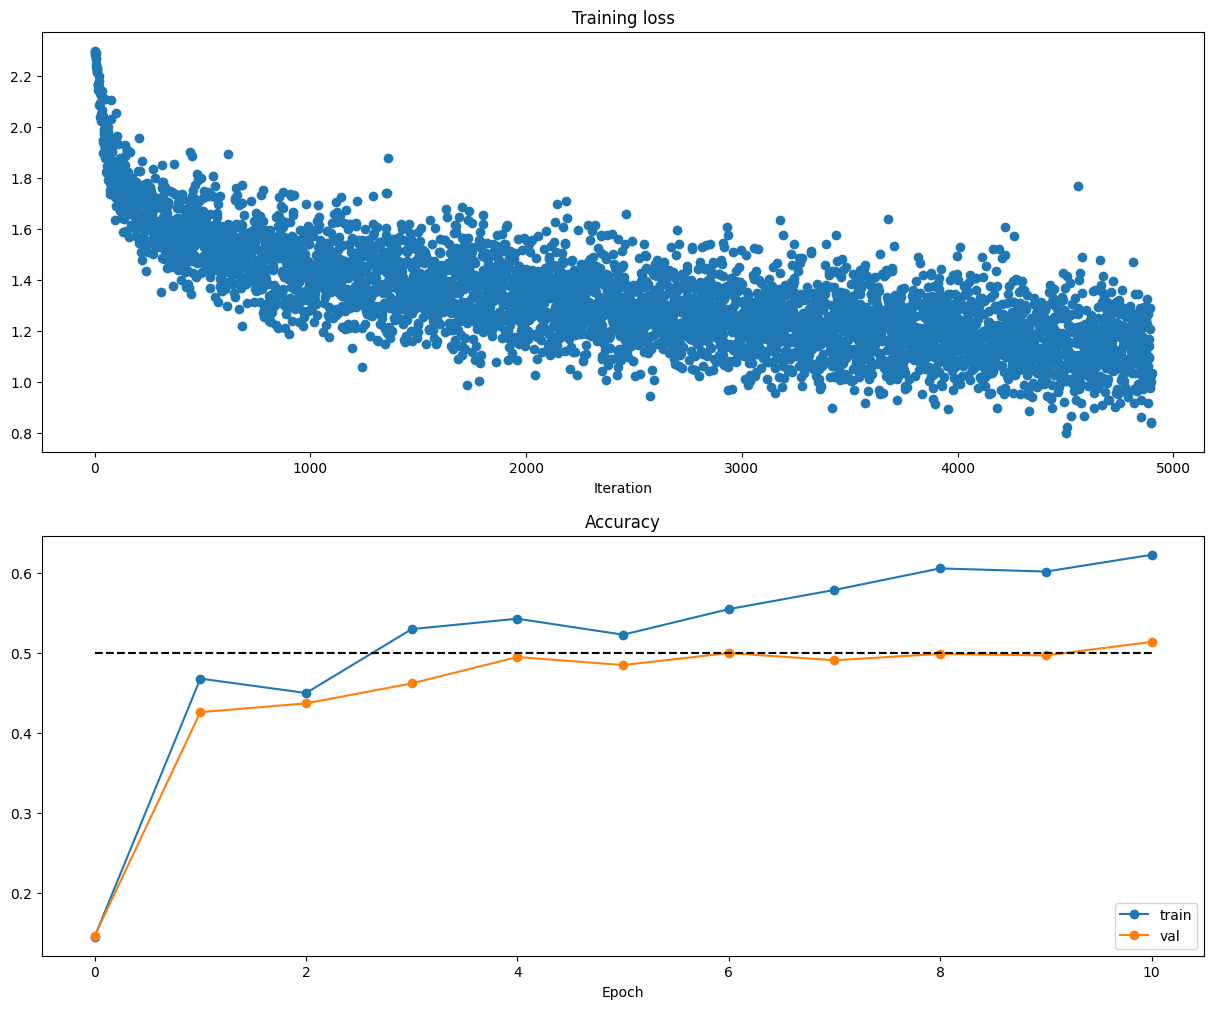

In [58]:
plt.subplot(2, 1, 1)
plt.title('Training loss')
plt.plot(solver.loss_history, 'o')
plt.xlabel('Iteration')

plt.subplot(2, 1, 2)
plt.title('Accuracy')
plt.plot(solver.train_acc_history, '-o', label='train')
plt.plot(solver.val_acc_history, '-o', label='val')
plt.plot([0.5] * len(solver.val_acc_history), 'k--')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.gcf().set_size_inches(15, 12)
plt.show()

#**Step 22: Final Accuracy**

In [59]:
best_model = model
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
val_acc = (y_val_pred == data['y_val']).mean()
print('Validation set accuracy: ', val_acc)

Validation set accuracy:  0.514


#**Final Step - Hyperparameter Tuning**

In [60]:
results = {}
best_val = -1
best_net = None

learning_rates = [1e-3, 5e-4]
regularization_strengths = [1e-3, 5e-3]

for lr in learning_rates:
    for reg in regularization_strengths:
        model = TwoLayerNetFixed(hidden_dim=100, reg=reg)
        solver = Solver(model, data, update_rule='sgd',
                        optim_config={'learning_rate': lr},
                        lr_decay=0.95, num_epochs=10,
                        batch_size=100, print_every=100, verbose=False)
        solver.train()

        val_acc = solver.val_acc_history[-1]
        results[(lr, reg)] = val_acc
        if val_acc > best_val:
            best_val = val_acc
            best_net = model

print('Best validation accuracy achieved during tuning: %f' % best_val)

Best validation accuracy achieved during tuning: 0.530000


#**Inline Question 2**

The gap between training and testing accuracy is a classic case of overfitting, where the model memorizes the training data instead of learning general patterns.

**$\color{blue}{\textit  Answer:}$**  
1 and 3  

**$\color{blue}{\textit  Explanation:}$**

**1. Train on a larger dataset (True):**  
Overfitting happens when the model captures noise or quirks from a small dataset. Adding more data forces the model to learn more stable, generalizable patterns, which reduces the gap between training and test performance.

**2. Add more hidden units (False):**  
Increasing hidden units raises the model’s capacity. While this may improve training accuracy, it often worsens overfitting because the network gains more ability to memorize noise.

**3. Increase the regularization strength (True):**  
Regularization (such as L2 penalty) discourages overly complex models. A higher regularization strength ($\lambda$) penalizes large weights, simplifies the model, and improves generalization to unseen data.
